# Week 2 - Preprocessing, part 2

# 1. Lesson: None

# 2. Weekly graph question

The Storytelling With Data book mentions planning on a "Who, What, and How" for your data story.  Write down a possible Who, What, and How for your data, using the ideas in the book.

## Who

NBA teams and coaching staff

## What

Which team performance metrics are most strongly associated with winning games

## How

By analyzing team-level game statistics such as shooting percentage, rebounds, assists, turnovers, and points scored, and measuring their relationship with game outcomes using statistical analysis and visualizations.


# 3. Homework - work with your own data

In [2]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do  Use Google, documentation, and ChatGPT to help you:

- Summarize the datasets using info() and describe()

- Are there any duplicate rows?

- Are there any duplicate values in a given column (when this would be inappropriate?)

- What are the mean, median, and mode of each column?

- Are there any missing or null values?

    - Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?

- Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

- Encode any categorical variables (e.g. with one-hot encoding.)

### Conclusions:

- Are the data usable?  If not, find some new data!

- Do you need to modify or correct the data in some way?

- Is there any class imbalance?  (Categories that have many more items than other categories).

In [50]:

df_player_stats = pd.read_csv("../milestone_data/player_stats/2023-2024_NBA_Player Stats_Regular.csv",
                  sep=";",
    encoding="cp1252")
pd.set_option('display.max_columns', None)
df_player_stats.head()
# df_player_stats.describe()

,Rk,Player,Pos,Age,Tm,G,GS,MP,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,2P%,eFG%,FT,FTA,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
0,1,Precious Achiuwa,PF-C,24,TOT,74,18,21.9,3.2,6.3,0.501,0.4,1.3,0.268,2.8,5.0,0.562,0.529,0.9,1.5,0.616,2.6,4.0,6.6,1.3,0.6,0.9,1.1,1.9,7.6
1,1,Precious Achiuwa,C,24,TOR,25,0,17.5,3.1,6.8,0.459,0.5,1.9,0.277,2.6,4.9,0.528,0.497,1.0,1.7,0.571,2.0,3.4,5.4,1.8,0.6,0.5,1.2,1.6,7.7
2,1,Precious Achiuwa,PF,24,NYK,49,18,24.2,3.2,6.1,0.525,0.3,1.0,0.260,2.9,5.1,0.578,0.547,0.9,1.4,0.643,2.9,4.3,7.2,1.1,0.6,1.1,1.1,2.1,7.6
3,2,Bam Adebayo,C,26,MIA,71,71,34.0,7.5,14.3,0.521,0.2,0.6,0.357,7.3,13.7,0.528,0.529,4.1,5.5,0.755,2.2,8.1,10.4,3.9,1.1,0.9,2.3,2.2,19.3
4,3,Ochai Agbaji,SG,23,TOT,78,28,21.0,2.3,5.6,0.411,0.8,2.7,0.294,1.5,2.8,0.523,0.483,0.5,0.7,0.661,0.9,1.8,2.8,1.1,0.6,0.6,0.8,1.5,5.8


In [51]:
#no duplicate rows
df_player_stats.duplicated().sum() 

np.int64(0)

In [52]:
df_player_stats[df_player_stats.duplicated(subset=['Player'], keep=False)]
#there are duplicate rows but they represent when a player was traded and played for mulitple teams in the season

,Rk,Player,Pos,Age,Tm,G,GS,MP,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,2P%,eFG%,FT,FTA,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
0,1,Precious Achiuwa,PF-C,24,TOT,74,18,21.9,3.2,6.3,0.501,0.4,1.3,0.268,2.8,5.0,0.562,0.529,0.9,1.5,0.616,2.6,4.0,6.6,1.3,0.6,0.9,1.1,1.9,7.6
1,1,Precious Achiuwa,C,24,TOR,25,0,17.5,3.1,6.8,0.459,0.5,1.9,0.277,2.6,4.9,0.528,0.497,1.0,1.7,0.571,2.0,3.4,5.4,1.8,0.6,0.5,1.2,1.6,7.7
2,1,Precious Achiuwa,PF,24,NYK,49,18,24.2,3.2,6.1,0.525,0.3,1.0,0.260,2.9,5.1,0.578,0.547,0.9,1.4,0.643,2.9,4.3,7.2,1.1,0.6,1.1,1.1,2.1,7.6
4,3,Ochai Agbaji,SG,23,TOT,78,28,21.0,2.3,5.6,0.411,0.8,2.7,0.294,1.5,2.8,0.523,0.483,0.5,0.7,0.661,0.9,1.8,2.8,1.1,0.6,0.6,0.8,1.5,5.8
5,3,Ochai Agbaji,SG,23,UTA,51,10,19.7,2.1,4.9,0.426,0.9,2.8,0.331,1.2,2.1,0.551,0.520,0.3,0.4,0.750,0.7,1.8,2.5,0.9,0.5,0.6,0.7,1.3,5.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,567,Delon Wright,PG,31,WAS,33,0,13.8,1.5,3.7,0.393,0.4,1.2,0.368,1.0,2.5,0.405,0.451,0.7,0.9,0.828,0.4,1.4,1.8,2.5,1.1,0.2,0.3,0.7,4.1
727,567,Delon Wright,PG,31,MIA,14,1,20.4,1.9,4.7,0.394,0.8,2.1,0.367,1.1,2.6,0.417,0.477,0.9,1.1,0.813,0.4,1.5,1.9,2.6,1.4,0.2,0.2,0.7,5.4
728,568,Thaddeus Young,PF,35,TOT,33,6,13.3,2.0,3.3,0.602,0.0,0.2,0.143,1.9,3.1,0.634,0.606,0.2,0.5,0.400,1.4,1.7,3.1,1.7,0.7,0.2,0.5,1.5,4.2
729,568,Thaddeus Young,PF,35,TOR,23,6,15.2,2.3,3.8,0.621,0.0,0.3,0.167,2.3,3.5,0.654,0.626,0.2,0.5,0.417,1.3,2.0,3.3,2.2,0.8,0.1,0.5,1.7,5.0


In [53]:
# Mean
print("MEAN")
print(df_player_stats.mean(numeric_only=True))

MEAN
Rk      282.209524
Age      26.155102
G        40.880272
GS       18.440816
MP       18.264762
FG        2.972789
FGA       6.423401
FG%       0.442687
3P        0.909116
3PA       2.582449
3P%       0.297090
2P        2.062721
2PA       3.840408
2P%       0.510494
eFG%      0.510079
FT        1.170884
FTA       1.509252
FT%       0.689493
ORB       0.822041
DRB       2.423265
TRB       3.239184
AST       1.934150
STL       0.587347
BLK       0.383946
TOV       0.943946
PF        1.456735
PTS       8.022313
dtype: float64


In [54]:
# Median
print("\nMEDIAN")
print(df_player_stats.median(numeric_only=True))


MEDIAN
Rk      290.000
Age      25.000
G        41.000
GS        5.000
MP       17.200
FG        2.300
FGA       5.000
FG%       0.446
3P        0.700
3PA       2.100
3P%       0.336
2P        1.500
2PA       2.800
2P%       0.528
eFG%      0.529
FT        0.800
FTA       1.000
FT%       0.760
ORB       0.600
DRB       2.100
TRB       2.800
AST       1.300
STL       0.500
BLK       0.300
TOV       0.700
PF        1.400
PTS       6.100
dtype: float64


In [55]:
# Mode (can return multiple values per column)
print("\nMODE")
print(df_player_stats.mode(numeric_only=True).iloc[0])


MODE
Rk      150.0
Age      24.0
G         6.0
GS        0.0
MP        3.0
FG        1.5
FGA       3.5
FG%       0.0
3P        0.0
3PA       0.0
3P%       0.0
2P        0.0
2PA       1.0
2P%       0.5
eFG%      0.5
FT        0.0
FTA       0.0
FT%       0.0
ORB       0.3
DRB       1.0
TRB       1.8
AST       1.3
STL       0.5
BLK       0.1
TOV       0.3
PF        1.0
PTS       0.0
Name: 0, dtype: float64


In [56]:
# no null values
df_player_stats.isnull().sum()


Rk        0
Player    0
Pos       0
Age       0
Tm        0
G         0
GS        0
MP        0
FG        0
FGA       0
FG%       0
3P        0
3PA       0
3P%       0
2P        0
2PA       0
2P%       0
eFG%      0
FT        0
FTA       0
FT%       0
ORB       0
DRB       0
TRB       0
AST       0
STL       0
BLK       0
TOV       0
PF        0
PTS       0
dtype: int64

In [57]:
#looking for inconsistent data
print("info - object types")
df_player_stats.info()
# Data types look consistent with expectation

info - object types
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 735 entries, 0 to 734
Data columns (total 30 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Rk      735 non-null    int64  
 1   Player  735 non-null    object 
 2   Pos     735 non-null    object 
 3   Age     735 non-null    int64  
 4   Tm      735 non-null    object 
 5   G       735 non-null    int64  
 6   GS      735 non-null    int64  
 7   MP      735 non-null    float64
 8   FG      735 non-null    float64
 9   FGA     735 non-null    float64
 10  FG%     735 non-null    float64
 11  3P      735 non-null    float64
 12  3PA     735 non-null    float64
 13  3P%     735 non-null    float64
 14  2P      735 non-null    float64
 15  2PA     735 non-null    float64
 16  2P%     735 non-null    float64
 17  eFG%    735 non-null    float64
 18  FT      735 non-null    float64
 19  FTA     735 non-null    float64
 20  FT%     735 non-null    float64
 21  ORB     735 non-nul

In [58]:
print("unique Tm - looking for wrong, missing, extra team names")
df_player_stats["Tm"].unique()
#outcome: only unexpected value is CHO which is a old version of charlotte hornets
#31 entries, 30 nba teams + 1 TOT wich is for total stats for a user if they played for more then one team


unique Tm - looking for wrong, missing, extra team names


array(['TOT', 'TOR', 'NYK', 'MIA', 'UTA', 'MEM', 'MIN', 'PHO', 'CLE',
       'NOP', 'MIL', 'ORL', 'WAS', 'POR', 'DET', 'CHO', 'PHI', 'BOS',
       'SAS', 'SAC', 'BRK', 'LAC', 'OKC', 'ATL', 'CHI', 'DEN', 'HOU',
       'IND', 'DAL', 'LAL', 'GSW'], dtype=object)

In [59]:
print("negative values - looking if anyone made negative stats which wouldn't happen")
(df_player_stats.select_dtypes(include="number") < 0).any().any()


negative values - looking if anyone made negative stats which wouldn't happen


np.False_

In [60]:
#I want to see if I need to one hot encode the POS vcolumn because there are instances of two positions.
df_player_stats[df_player_stats["Pos"].str.contains("-", na=False)]["Tm"].value_counts()
#Outcome: only complex position types only exists if team is TOT (total)
#I dont think there are any columns that need one hot encoding in THIS data set

Tm
TOT    13
Name: count, dtype: int64

## Conclusion ##

- The data is in a fantastic state for what my use case would be. I think I can easily sperate this data and drill down to a single player/team and see there impact. If this data set is paired with outcomes I believe I could identify threshholds of impact player by player

- THe data is in a clean state already. 

- The only categorical column that would contain slightly too many options (Tm: team) which has TOT: total as an option. I think for my purpose I will query out TOT because i am more focused on Team focused analyisis not player focused information.

# 4. Storytelling With Data graph

Just like last week: choose any graph in the Introduction of Storytelling With Data (p. 1-17). Use matplotlib to reproduce it in a rough way. I don't expect you to spend an enormous amount of time on this; I understand that you likely will not have time to re-create every feature of the graph. However, if you're excited about learning to use matplotlib, this is a good way to do that. You don't have to duplicate the exact values on the graph; just the same rough shape will be enough.  If you don't feel comfortable using matplotlib yet, do the best you can and write down what you tried or what Google searches you did to find the answers.

In [65]:
import matplotlib.pyplot as plt
df_customers = pd.DataFrame({
    "USPopulation": [5400, 2950, 2350, 2300, 3000, 1700, 2300],
    "OurCustomers": [400, 450, 350, 300, 500, 200, 800]
})

df_customers.head()

,USPopulation,OurCustomers
0,5400,400
1,2950,450
2,2350,350
3,2300,300
4,3000,500


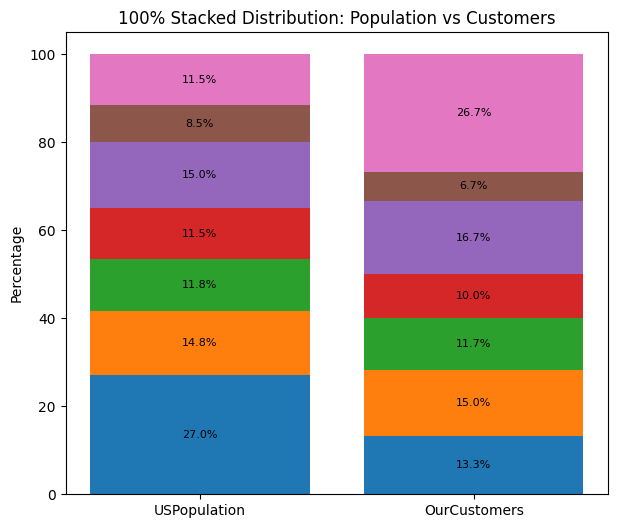

In [72]:
df_pct = df_customers.div(df_customers.sum(), axis=1) * 100
df_pct

plt.figure(figsize=(7,6))


colors = plt.cm.tab10.colors  # consistent palette
segments = df_pct.index

bottom_pop = 0
bottom_cust = 0
for i, seg in enumerate(segments):
    pop_val = df_pct.loc[seg, "USPopulation"]
    cust_val = df_pct.loc[seg, "OurCustomers"]

    # Population bar
    plt.bar("USPopulation", pop_val, bottom=bottom_pop, color=colors[i % 10], label=seg)
    plt.text(
        0,
        bottom_pop + pop_val / 2,
        f"{pop_val:.1f}%",
        ha="center",
        va="center",
        fontsize=8
    )

    # Customers bar
    plt.bar("OurCustomers", cust_val, bottom=bottom_cust, color=colors[i % 10])
    plt.text(
        1,
        bottom_cust + cust_val / 2,
        f"{cust_val:.1f}%",
        ha="center",
        va="center",
        fontsize=8
    )

    bottom_pop += pop_val
    bottom_cust += cust_val

plt.ylabel("Percentage")
plt.title("100% Stacked Distribution: Population vs Customers")
plt.show()